# NCA Parent ML — annual-z IA45 with coarse K=5 vegetation labels

This notebook reruns the **optical-only annual-z supervised classification** using the independently refit vegetation FCM solution:

- K = 5
- m = 1.33
- label 1 = **PBG**
- label 2 = **ARTR**
- label 3 = **Non-ARTR shrub**
- label 4 = **Exotic forb**
- label 5 = **EAG**

The scientific change is deliberately narrow: **replace the eight vegetation-parent labels with the five coarse FCM labels while keeping the optical representation and learner architecture unchanged.**

For direct comparability, this notebook **reuses the already-saved S500 annual z-score parameters from the previous optical-only run** instead of recomputing normalization. Thus the principal change is the response label resolution.

Validation includes grouped out-of-fold prediction by PlotID and leave-one-year-out temporal transfer. The random forest remains the default mapping model. Raster mapping is disabled by default and can be enabled after reviewing validation.

All outputs are isolated under a new K5-specific directory and the notebook refuses to overwrite an existing populated output directory unless `ALLOW_OVERWRITE = True` is explicitly set.

In [ ]:
# =============================================================================
# 0. IMPORTS / PATHS / SETTINGS
# =============================================================================

from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 280)


# -----------------------------------------------------------------------------
# INPUTS
# -----------------------------------------------------------------------------

VEG_TRAINING_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

K5_ASSIGNMENTS_CSV = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived"
    r"\NCA_FCM_K5_m1p33_parent_assignments.csv"
)

# Reuse the exact S500 annual normalization parameters from the previous
# optical-only z-score classification. This keeps the predictor representation
# fixed while changing only the vegetation labels.
ZSCORE_PARAMETER_CSV = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
    r"\annual_IA45_zscore_parameters_S500.csv"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)


# -----------------------------------------------------------------------------
# OUTPUT — completely separate from K8 products
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5"
)

ALLOW_OVERWRITE = True

if OUTPUT_DIR.exists():
    existing_files = [
        p
        for p in OUTPUT_DIR.rglob("*")
        if p.is_file()
    ]

    if existing_files and not ALLOW_OVERWRITE:
        raise FileExistsError(
            "K5 output directory already contains files. "
            "Stopping rather than overwriting an existing run.\n"
            f"Set ALLOW_OVERWRITE=True only if replacement is intentional.\n\n"
            f"{OUTPUT_DIR}"
        )

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# ANALYSIS SETTINGS
# -----------------------------------------------------------------------------

YEARS_TO_MAP = list(range(2016, 2026))
VEG_YEARS = [2016, 2018, 2025]
EXPECTED_D = 45

K5_CODES = [1, 2, 3, 4, 5]

K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}

VEG_CLASSES = [
    f"K5::{i}"
    for i in K5_CODES
]

CLASS_TO_CODE = {
    f"K5::{i}": i
    for i in K5_CODES
}

CODE_TO_CLASS = {
    code: cls
    for cls, code in CLASS_TO_CODE.items()
}

RANDOM_STATE = 42
N_SPLITS = 5
COMPRESS = "DEFLATE"
MODEL_FOR_MAPPING = "random_forest"

# Keep False to preserve the same broad support logic as the previous baseline.
FILTER_TRAINING_TO_MASK = False

# Validation runs first. Flip to True only after reviewing the results.
RUN_ALL_YEAR_MAPPING = True


print("Vegetation optical table:", VEG_TRAINING_CSV)
print("K5 assignments:          ", K5_ASSIGNMENTS_CSV)
print("Z-score parameters:      ", ZSCORE_PARAMETER_CSV)
print("Harmonic root:           ", HARMONIC_ROOT)
print("Mask:                    ", KEEP_MASK)
print("Output:                  ", OUTPUT_DIR)
print("Mapping enabled:         ", RUN_ALL_YEAR_MAPPING)

FileExistsError: K5 output directory already contains files. Stopping rather than overwriting an existing run.
Set ALLOW_OVERWRITE=True only if replacement is intentional.

C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5

## 1. Load the saved annual S500 z-score parameters

The previous optical-only run wrote one mean and SD for every year × IA45 feature combination. We reuse those values here so the five-label experiment changes the response variable, not the optical coordinate system.

In [ ]:
# =============================================================================
# 1. LOAD EXISTING S500 Z-SCORE PARAMETERS
# =============================================================================

if not ZSCORE_PARAMETER_CSV.exists():
    raise FileNotFoundError(
        f"Saved S500 z-score parameter file not found:\n{ZSCORE_PARAMETER_CSV}"
    )

reference_parameters = pd.read_csv(
    ZSCORE_PARAMETER_CSV
)

required_cols = {
    "Year",
    "feature",
    "weighted_mean",
    "weighted_sd",
}

missing = required_cols.difference(
    reference_parameters.columns
)

if missing:
    raise KeyError(
        f"Z-score parameter table is missing columns: {sorted(missing)}"
    )

reference_parameters["Year"] = pd.to_numeric(
    reference_parameters["Year"],
    errors="raise",
).astype(int)

# Preserve feature order from the first mapped year.
SAMPLE_IA_COLS = (
    reference_parameters.loc[
        reference_parameters["Year"].eq(YEARS_TO_MAP[0]),
        "feature",
    ]
    .astype(str)
    .tolist()
)

if len(SAMPLE_IA_COLS) != EXPECTED_D:
    raise ValueError(
        f"Expected {EXPECTED_D} IA45 features; found {len(SAMPLE_IA_COLS)}."
    )

for year in YEARS_TO_MAP:
    n_year = reference_parameters.loc[
        reference_parameters["Year"].eq(year)
    ].shape[0]

    if n_year != EXPECTED_D:
        raise ValueError(
            f"{year}: expected {EXPECTED_D} z-score rows; found {n_year}."
        )

print("IA45 feature count:", len(SAMPLE_IA_COLS))
print("Years available:", sorted(reference_parameters["Year"].unique()))
print("First 10 features:")
print(SAMPLE_IA_COLS[:10])

IA45 feature count: 45
Years available: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
First 10 features:
['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6', 'constant_B7', 'constant_B8', 'constant_B8A', 'constant_B11', 'constant_B12']


## 2. Load optical field observations and attach the K=5 vegetation labels

The optical table provides the annual IA45 values at monitored plots. The K5 FCM assignment table provides the new coarse vegetation response.

The join is performed on normalized plot identifier + year. The notebook reports any unmatched rows rather than silently assuming equivalence.

In [ ]:
# =============================================================================
# 2. LOAD FIELD OPTICAL DATA + K5 LABELS
# =============================================================================

for path in [
    VEG_TRAINING_CSV,
    K5_ASSIGNMENTS_CSV,
]:
    if not path.exists():
        raise FileNotFoundError(path)

veg = pd.read_csv(
    VEG_TRAINING_CSV,
    low_memory=False,
).drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

k5 = pd.read_csv(
    K5_ASSIGNMENTS_CSV,
    low_memory=False,
).drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


def normalize_plot_id(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s


# Field table uses PlotID in the established supervised workflow.
if "PlotID" not in veg.columns:
    raise KeyError("Field optical table must contain PlotID.")

# K5 assignment table inherited the vegetation master; it normally uses Plot.
if "Plot" in k5.columns:
    K5_PLOT_COL = "Plot"
elif "PlotID" in k5.columns:
    K5_PLOT_COL = "PlotID"
else:
    raise KeyError("K5 assignment table must contain Plot or PlotID.")

for df in [veg, k5]:
    df["Year"] = pd.to_numeric(
        df["Year"],
        errors="coerce",
    )

veg = veg.loc[
    veg["Year"].isin(VEG_YEARS)
].copy()

k5 = k5.loc[
    k5["Year"].isin(VEG_YEARS)
].copy()

veg["Year"] = veg["Year"].astype(int)
k5["Year"] = k5["Year"].astype(int)

veg["_join_plot"] = veg["PlotID"].map(normalize_plot_id)
k5["_join_plot"] = k5[K5_PLOT_COL].map(normalize_plot_id)

if "parent_cluster_k5" not in k5.columns:
    raise KeyError(
        "K5 assignment table must contain parent_cluster_k5."
    )

k5["parent_cluster_k5"] = pd.to_numeric(
    k5["parent_cluster_k5"],
    errors="coerce",
)

k5 = k5.loc[
    k5["parent_cluster_k5"].isin(K5_CODES)
].copy()

k5["parent_cluster_k5"] = k5["parent_cluster_k5"].astype(int)

JOIN_KEYS = ["_join_plot", "Year"]

if veg.duplicated(JOIN_KEYS).any():
    dup = veg.loc[
        veg.duplicated(JOIN_KEYS, keep=False),
        JOIN_KEYS,
    ].head(20)
    raise ValueError(
        "Field optical table contains duplicate normalized Plot-Year keys.\n"
        + dup.to_string(index=False)
    )

if k5.duplicated(JOIN_KEYS).any():
    dup = k5.loc[
        k5.duplicated(JOIN_KEYS, keep=False),
        JOIN_KEYS,
    ].head(20)
    raise ValueError(
        "K5 assignment table contains duplicate normalized Plot-Year keys.\n"
        + dup.to_string(index=False)
    )

k5_keep = [
    "_join_plot",
    "Year",
    "parent_cluster_k5",
]

for c in [
    "max_membership_k5",
    "membership_margin_k5",
]:
    if c in k5.columns:
        k5_keep.append(c)

merged = veg.merge(
    k5[k5_keep],
    on=JOIN_KEYS,
    how="left",
    validate="one_to_one",
    indicator=True,
)

unmatched = merged.loc[
    merged["_merge"].ne("both")
].copy()

print("Field optical rows in vegetation years:", len(veg))
print("Matched to K5 labels:                  ", int((merged["_merge"] == "both").sum()))
print("Unmatched field rows:                  ", len(unmatched))

if len(unmatched) > 0:
    display(
        unmatched[
            ["PlotID", "Year", "_join_plot"]
        ].head(30)
    )

veg = (
    merged.loc[
        merged["_merge"].eq("both")
    ]
    .drop(columns=["_merge"])
    .reset_index(drop=True)
)

veg["parent_cluster_k5"] = veg["parent_cluster_k5"].astype(int)
veg["k5_label"] = veg["parent_cluster_k5"].map(K5_LABELS)

print("\nK5 training-label counts:")
display(
    veg.groupby(
        ["parent_cluster_k5", "k5_label"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n"})
)

print("\nYear counts:")
display(
    veg["Year"]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
)

Field optical rows in vegetation years: 479
Matched to K5 labels:                   479
Unmatched field rows:                   0

K5 training-label counts:


,parent_cluster_k5,k5_label,n
0,1,PBG,109
1,2,ARTR,36
2,3,Non-ARTR shrub,109
3,4,Exotic forb,93
4,5,EAG,132



Year counts:


,n
Year,
2016,255
2018,106
2025,118


## 3. Align the 45 IA features and build annual-z predictors

In [ ]:
# =============================================================================
# 3. IA45 ALIGNMENT + YEAR-SPECIFIC Z-SCORING
# =============================================================================


def normalize_feature_name(x):
    return str(x).strip().lower()


# Detect intercept and amplitude columns exactly as in the previous workflow.
veg_candidate_cols = []

for col in veg.columns:
    lower = normalize_feature_name(col)

    is_intercept = (
        re.search(
            r"(^|_)(intercept|constant)($|_)",
            lower,
        )
        is not None
    )

    is_amplitude = (
        re.search(
            r"(^|_)(amp|amplitude)",
            lower,
        )
        is not None
    )

    if is_intercept or is_amplitude:
        veg_candidate_cols.append(col)

if len(veg_candidate_cols) != EXPECTED_D:
    raise ValueError(
        f"Expected {EXPECTED_D} IA45 columns in vegetation table; "
        f"found {len(veg_candidate_cols)}."
    )

sample_lookup = {
    normalize_feature_name(c): c
    for c in SAMPLE_IA_COLS
}

veg_to_sample = {}

for veg_col in veg_candidate_cols:
    key = normalize_feature_name(veg_col)

    if key not in sample_lookup:
        raise KeyError(
            f"Vegetation IA45 feature does not match saved z-score schema: {veg_col}"
        )

    veg_to_sample[veg_col] = sample_lookup[key]

sample_to_veg = {
    sample_name: veg_name
    for veg_name, sample_name in veg_to_sample.items()
}

VEG_IA_COLS = [
    sample_to_veg[feature]
    for feature in SAMPLE_IA_COLS
]


# Build year lookup from saved S500 parameters.
reference_lookup = {}

for year in YEARS_TO_MAP:
    year_params = (
        reference_parameters.loc[
            reference_parameters["Year"].eq(year)
        ]
        .set_index("feature")
        .loc[SAMPLE_IA_COLS]
    )

    means = year_params["weighted_mean"].to_numpy(dtype=np.float64)
    sds = year_params["weighted_sd"].to_numpy(dtype=np.float64)

    if (
        (~np.isfinite(means)).any()
        or (~np.isfinite(sds)).any()
        or (sds <= 0).any()
    ):
        raise ValueError(
            f"Invalid normalization parameters for {year}."
        )

    reference_lookup[year] = {
        "mean": means,
        "sd": sds,
    }


X_raw = (
    veg[VEG_IA_COLS]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=np.float64)
)

if not np.isfinite(X_raw).all():
    raise ValueError(
        "Vegetation training table contains invalid IA45 values."
    )

X_z = np.full_like(
    X_raw,
    np.nan,
    dtype=np.float64,
)

years_veg = veg["Year"].to_numpy(dtype=int)

for year in np.unique(years_veg):
    mask = years_veg == year
    params = reference_lookup[int(year)]

    X_z[mask] = (
        X_raw[mask]
        - params["mean"]
    ) / params["sd"]

if not np.isfinite(X_z).all():
    raise ValueError(
        "Non-finite values remain after annual z-scoring."
    )

# Preserve string response convention used in the earlier ML notebooks.
y = (
    "K5::"
    + veg["parent_cluster_k5"].astype(str)
).to_numpy()

groups = veg["PlotID"].astype(str).to_numpy()

print("Training matrix:", X_z.shape)
print("Classes:", sorted(np.unique(y)))

Training matrix: (479, 45)
Classes: ['K5::1', 'K5::2', 'K5::3', 'K5::4', 'K5::5']


## 4. Optional mapping-mask filter

Leave this off for the cleanest comparison to the previous optical-only classifier. If enabled later, it restricts training observations to the current keep-mask support.

In [ ]:
# =============================================================================
# 4. OPTIONAL TRAINING MASK FILTER
# =============================================================================


def mask_keep_for_points(
    table,
    x_col,
    y_col,
    mask_path,
):
    keep_flags = []

    with rasterio.open(mask_path) as src:
        nodata = src.nodata

        coords = list(
            zip(
                table[x_col].astype(float),
                table[y_col].astype(float),
            )
        )

        for value in src.sample(
            coords,
            indexes=1,
            masked=False,
        ):
            v = value[0]
            valid = np.isfinite(v)

            if nodata is not None:
                valid &= not np.isclose(v, nodata)

            keep_flags.append(
                bool(valid and v > 0)
            )

    return np.asarray(
        keep_flags,
        dtype=bool,
    )


if FILTER_TRAINING_TO_MASK:
    required_xy = ["Easting", "Northing"]

    if not all(c in veg.columns for c in required_xy):
        raise KeyError(
            "Mask filtering requires Easting and Northing in vegetation table."
        )

    keep_training = mask_keep_for_points(
        veg,
        "Easting",
        "Northing",
        KEEP_MASK,
    )

    print(
        "Rows retained by mapping mask:",
        int(keep_training.sum()),
        "/",
        len(veg),
    )

    veg = veg.loc[keep_training].copy().reset_index(drop=True)
    X_z = X_z[keep_training]
    y = y[keep_training]
    groups = groups[keep_training]
    years_veg = years_veg[keep_training]

print("Final modeling rows:", len(veg))

Final modeling rows: 479


## 5. Candidate learners

These are the same learner settings used in the previous annual-z optical-only notebook. No K5-specific hyperparameter tuning is introduced.

In [ ]:
# =============================================================================
# 5. MODELS
# =============================================================================

MODELS = {
    "elastic_net_logistic": Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                l1_ratio=0.5,
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "random_forest": RandomForestClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}


def score_predictions(
    y_true,
    y_pred,
):
    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
    }

## 6. Grouped out-of-fold validation

Each PlotID is held entirely within one fold. These scores describe prediction at held-out monitored observations rather than wall-to-wall pixel accuracy.

In [ ]:
# =============================================================================
# 6. GROUPED OOF
# =============================================================================

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

CV_SPLITS = list(
    cv.split(
        X_z,
        y,
        groups,
    )
)

fold_rows = []
oof_predictions = {}

for model_name, template in MODELS.items():
    pred_all = np.empty(
        len(veg),
        dtype=object,
    )
    pred_all[:] = None

    for fold, (train_idx, test_idx) in enumerate(
        CV_SPLITS,
        start=1,
    ):
        fitted = clone(template)

        fitted.fit(
            X_z[train_idx],
            y[train_idx],
        )

        pred = fitted.predict(
            X_z[test_idx]
        ).astype(str)

        pred_all[test_idx] = pred

        fold_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                **score_predictions(
                    y[test_idx],
                    pred,
                ),
            }
        )

    oof_predictions[model_name] = pred_all


oof_fold_metrics = pd.DataFrame(fold_rows)

oof_pooled_rows = []

for model_name, pred in oof_predictions.items():
    oof_pooled_rows.append(
        {
            "model": model_name,
            "n": len(y),
            **score_predictions(
                y,
                pred,
            ),
        }
    )

oof_pooled = pd.DataFrame(oof_pooled_rows)


oof_fold_metrics.to_csv(
    OUTPUT_DIR / "K5_AnnualZScore_groupedOOF_fold_metrics.csv",
    index=False,
)

oof_pooled.to_csv(
    OUTPUT_DIR / "K5_AnnualZScore_groupedOOF_pooled_metrics.csv",
    index=False,
)

print("Pooled grouped-OOF metrics:")
display(
    oof_pooled.sort_values(
        "macro_f1",
        ascending=False,
    ).round(4)
)

Pooled grouped-OOF metrics:


,model,n,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
2,extra_trees,479,0.5929,0.5754,0.5889,0.5754,0.5810
0,elastic_net_logistic,479,0.5866,0.5929,0.5663,0.5929,0.5723
1,random_forest,479,0.5804,0.5458,0.5667,0.5458,0.5530


## 7. Random-forest classwise OOF performance and confusion matrix

In [ ]:
# =============================================================================
# 7. CLASSWISE OOF — RANDOM FOREST
# =============================================================================

rf_pred = np.asarray(
    oof_predictions[MODEL_FOR_MAPPING],
    dtype=str,
)

report = classification_report(
    y,
    rf_pred,
    labels=VEG_CLASSES,
    target_names=[
        K5_LABELS[i]
        for i in K5_CODES
    ],
    output_dict=True,
    zero_division=0,
)

classwise_rows = []

for code, class_name in zip(
    K5_CODES,
    VEG_CLASSES,
):
    label = K5_LABELS[code]
    r = report[label]

    classwise_rows.append(
        {
            "class_code": code,
            "class_label": label,
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1-score"],
            "support": int(r["support"]),
        }
    )

classwise_oof = pd.DataFrame(classwise_rows)

classwise_oof.to_csv(
    OUTPUT_DIR / "K5_AnnualZScore_RF_classwise_OOF.csv",
    index=False,
)

print("RF classwise OOF:")
display(
    classwise_oof.round(3)
)

cm = confusion_matrix(
    y,
    rf_pred,
    labels=VEG_CLASSES,
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"True {K5_LABELS[i]}"
        for i in K5_CODES
    ],
    columns=[
        f"Pred {K5_LABELS[i]}"
        for i in K5_CODES
    ],
)

cm_df.to_csv(
    OUTPUT_DIR / "K5_AnnualZScore_RF_OOF_confusion.csv"
)

display(cm_df)

RF classwise OOF:


,class_code,class_label,precision,recall,f1,support
0,1,PBG,0.553,0.523,0.538,109
1,2,ARTR,0.520,0.361,0.426,36
2,3,Non-ARTR shrub,0.535,0.560,0.547,109
3,4,Exotic forb,0.574,0.581,0.578,93
4,5,EAG,0.650,0.705,0.676,132


,Pred PBG,Pred ARTR,Pred Non-ARTR shrub,Pred Exotic forb,Pred EAG
True PBG,57,0,13,17,22
True ARTR,0,13,17,1,5
True Non-ARTR shrub,17,8,61,10,13
True Exotic forb,13,2,14,54,10
True EAG,16,2,9,12,93


## 8. Leave-one-year-out temporal transfer

For each monitored year, every vegetation label from that year is withheld during fitting. The target-year S500 optical normalization remains available because it is estimated from unlabeled imagery, not vegetation labels.

In [ ]:
# =============================================================================
# 8. LEAVE-ONE-YEAR-OUT
# =============================================================================

loyo_rows = []
loyo_confusion_rows = []

for model_name, template in MODELS.items():
    for held_year in VEG_YEARS:
        train_mask = years_veg != held_year
        test_mask = years_veg == held_year

        fitted = clone(template)

        fitted.fit(
            X_z[train_mask],
            y[train_mask],
        )

        pred = fitted.predict(
            X_z[test_mask]
        ).astype(str)

        loyo_rows.append(
            {
                "model": model_name,
                "held_out_year": held_year,
                "n_train": int(train_mask.sum()),
                "n_test": int(test_mask.sum()),
                **score_predictions(
                    y[test_mask],
                    pred,
                ),
            }
        )

        cm = confusion_matrix(
            y[test_mask],
            pred,
            labels=VEG_CLASSES,
        )

        for true_i, true_code in enumerate(K5_CODES):
            for pred_i, pred_code in enumerate(K5_CODES):
                loyo_confusion_rows.append(
                    {
                        "model": model_name,
                        "held_out_year": held_year,
                        "true_code": true_code,
                        "true_label": K5_LABELS[true_code],
                        "predicted_code": pred_code,
                        "predicted_label": K5_LABELS[pred_code],
                        "n": int(cm[true_i, pred_i]),
                    }
                )


loyo_df = pd.DataFrame(loyo_rows)
loyo_confusion_df = pd.DataFrame(loyo_confusion_rows)

loyo_df.to_csv(
    OUTPUT_DIR / "K5_AnnualZScore_leaveYearOut.csv",
    index=False,
)

loyo_confusion_df.to_csv(
    OUTPUT_DIR / "K5_AnnualZScore_leaveYearOut_confusion_long.csv",
    index=False,
)

print("Leave-one-year-out metrics:")
display(
    loyo_df.sort_values(
        ["held_out_year", "model"],
    ).round(4)
)

Leave-one-year-out metrics:


,model,held_out_year,n_train,n_test,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,elastic_net_logistic,2016,224,255,0.3725,0.3754,0.3819,0.3754,0.3595
6,extra_trees,2016,224,255,0.3647,0.3517,0.3765,0.3517,0.3565
3,random_forest,2016,224,255,0.3843,0.3610,0.3952,0.3610,0.3684
1,elastic_net_logistic,2018,373,106,0.4623,0.4938,0.4540,0.4938,0.4441
7,extra_trees,2018,373,106,0.4906,0.4720,0.4496,0.4720,0.4444
4,random_forest,2018,373,106,0.5283,0.4787,0.4720,0.4787,0.4635
2,elastic_net_logistic,2025,361,118,0.4831,0.5026,0.4943,0.5026,0.4652
8,extra_trees,2025,361,118,0.4576,0.5021,0.4823,0.5021,0.4323
5,random_forest,2025,361,118,0.4492,0.4628,0.4764,0.4628,0.4067


## 9. Save the explicit K5 modeling dataset

This creates a reusable table containing the matched field observations, the five-class label, and the 45 annual-z optical predictors.

In [ ]:
# =============================================================================
# 9. SAVE MODELING DATASET
# =============================================================================

modeling_dataset = veg[
    [
        c
        for c in [
            "PlotID",
            "Year",
            "parent_cluster_k5",
            "k5_label",
            "Easting",
            "Northing",
            "max_membership_k5",
            "membership_margin_k5",
        ]
        if c in veg.columns
    ]
].copy()

for j, feature in enumerate(SAMPLE_IA_COLS):
    modeling_dataset[f"z__{feature}"] = X_z[:, j]

MODELING_DATASET_PATH = (
    OUTPUT_DIR
    / "FieldVeg_K5_AnnualZScore_IA45_modeling_dataset.csv"
)

modeling_dataset.to_csv(
    MODELING_DATASET_PATH,
    index=False,
)

print("Wrote:", MODELING_DATASET_PATH)
print("Rows:", len(modeling_dataset))

Wrote: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5\FieldVeg_K5_AnnualZScore_IA45_modeling_dataset.csv
Rows: 479


## 10. Fit the final random-forest mapping model

This model uses all matched monitored observations. The raster maps are therefore production predictions from the full training set; the OOF and LOYO results above are the held-out validation results.

In [ ]:
# =============================================================================
# 10. FINAL MAPPING MODEL
# =============================================================================

mapping_model = clone(
    MODELS[MODEL_FOR_MAPPING]
)

t0 = time.perf_counter()

mapping_model.fit(
    X_z,
    y,
)

print("Mapping model:", MODEL_FOR_MAPPING)
print("Training rows:", len(veg))
print("Classes:", mapping_model.classes_)
print(
    "Fit time:",
    f"{(time.perf_counter() - t0) / 60:.2f} min",
)

Mapping model: random_forest
Training rows: 479
Classes: ['K5::1' 'K5::2' 'K5::3' 'K5::4' 'K5::5']
Fit time: 0.01 min


## 11. Raster helpers and annual blockwise mapping

Class raster codes are the K5 labels directly:

1. PBG
2. ARTR
3. Non-ARTR shrub
4. Exotic forb
5. EAG

Uncertainty raster bands are relative model diagnostics: maximum class probability, top-two probability margin, and prediction entropy.

In [ ]:
# =============================================================================
# 11. RASTER HELPERS
# =============================================================================


def annual_k2_path(year):
    return (
        HARMONIC_ROOT
        / str(year)
        / f"{year}_K2_InterceptAmpPhase_nobs_RMSE.tif"
    )


def get_band_names(src):
    return [
        (
            str(desc).strip()
            if desc is not None and str(desc).strip()
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def ia_band_indexes(
    src,
    feature_names,
):
    band_names = get_band_names(src)

    lookup = {
        normalize_feature_name(name): i
        for i, name in enumerate(
            band_names,
            start=1,
        )
    }

    indexes = []
    missing = []

    for feature in feature_names:
        key = normalize_feature_name(feature)

        if key not in lookup:
            missing.append(feature)
        else:
            indexes.append(lookup[key])

    if missing:
        raise KeyError(
            "Missing annual raster IA45 bands:\n"
            + "\n".join(missing)
        )

    if len(indexes) != EXPECTED_D:
        raise RuntimeError(
            f"Expected {EXPECTED_D} raster indexes; found {len(indexes)}."
        )

    return indexes


def grids_match(src_a, src_b):
    return (
        src_a.width == src_b.width
        and src_a.height == src_b.height
        and src_a.transform == src_b.transform
        and src_a.crs == src_b.crs
    )


def predictive_entropy(proba):
    eps = 1e-12
    return -np.sum(
        proba
        * np.log(
            np.maximum(proba, eps)
        ),
        axis=1,
    )


for year in YEARS_TO_MAP:
    path = annual_k2_path(year)

    if not path.exists():
        raise FileNotFoundError(
            f"Missing annual harmonic raster:\n{path}"
        )

    with rasterio.open(path) as src:
        indexes = ia_band_indexes(
            src,
            SAMPLE_IA_COLS,
        )

    print(year, "| aligned IA45:", len(indexes))

2016 | aligned IA45: 45
2017 | aligned IA45: 45
2018 | aligned IA45: 45
2019 | aligned IA45: 45
2020 | aligned IA45: 45
2021 | aligned IA45: 45
2022 | aligned IA45: 45
2023 | aligned IA45: 45
2024 | aligned IA45: 45
2025 | aligned IA45: 45


In [ ]:
# =============================================================================
# 12. BLOCKWISE K5 MAPPING FUNCTION
# =============================================================================


def classify_year_zscore_k5(
    year,
    model,
):
    src_path = annual_k2_path(year)

    class_path = (
        OUTPUT_DIR
        / f"K5_AnnualZScore_{MODEL_FOR_MAPPING}_{year}_class.tif"
    )

    uncertainty_path = (
        OUTPUT_DIR
        / f"K5_AnnualZScore_{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
    )

    if not ALLOW_OVERWRITE:
        existing = [
            p
            for p in [class_path, uncertainty_path]
            if p.exists()
        ]

        if existing:
            raise FileExistsError(
                "Refusing to overwrite existing K5 raster outputs:\n"
                + "\n".join(str(p) for p in existing)
            )

    params = reference_lookup[int(year)]
    mu = params["mean"].astype(np.float32)
    sigma = params["sd"].astype(np.float32)

    print("\n" + "=" * 100)
    print(f"CLASSIFYING {year} — K5 ANNUAL Z-SCORED IA45")
    print("=" * 100)

    year_start = time.perf_counter()

    with rasterio.open(src_path) as src, rasterio.open(KEEP_MASK) as mask_src:
        indexes = ia_band_indexes(
            src,
            SAMPLE_IA_COLS,
        )

        use_direct_mask = grids_match(
            src,
            mask_src,
        )

        mask_vrt = None

        if not use_direct_mask:
            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )

        blocks = list(
            src.block_windows(1)
        )

        n_blocks = len(blocks)

        class_profile = src.profile.copy()
        class_profile.update(
            driver="GTiff",
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        uncertainty_profile = src.profile.copy()
        uncertainty_profile.update(
            driver="GTiff",
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        model_classes = np.asarray(
            model.classes_,
            dtype=object,
        )

        total_valid = 0

        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_k5_vegetation_class",
            )

            uncertainty_dst.set_band_description(1, "max_probability")
            uncertainty_dst.set_band_description(2, "probability_margin")
            uncertainty_dst.set_band_description(3, "prediction_entropy")

            for block_number, (_, window) in enumerate(
                blocks,
                start=1,
            ):
                if use_direct_mask:
                    keep = mask_src.read(
                        1,
                        window=window,
                        masked=False,
                    )
                else:
                    keep = mask_vrt.read(
                        1,
                        window=window,
                        masked=False,
                    )

                keep_valid = (
                    np.isfinite(keep)
                    & (keep > 0)
                )

                features = src.read(
                    indexes,
                    window=window,
                    masked=False,
                ).astype(
                    np.float32,
                    copy=False,
                )

                features = np.moveaxis(
                    features,
                    0,
                    -1,
                )

                valid = (
                    keep_valid
                    & np.isfinite(features).all(axis=2)
                )

                if src.nodata is not None:
                    valid &= ~np.any(
                        np.isclose(
                            features,
                            src.nodata,
                        ),
                        axis=2,
                    )

                n_valid = int(valid.sum())
                total_valid += n_valid

                class_block = np.zeros(
                    (
                        int(window.height),
                        int(window.width),
                    ),
                    dtype=np.uint8,
                )

                uncertainty_block = np.full(
                    (
                        3,
                        int(window.height),
                        int(window.width),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )

                if n_valid > 0:
                    X_block_raw = features[valid]
                    X_block_z = (
                        X_block_raw
                        - mu
                    ) / sigma

                    proba = model.predict_proba(
                        X_block_z
                    ).astype(
                        np.float32,
                        copy=False,
                    )

                    winner_idx = np.argmax(
                        proba,
                        axis=1,
                    )

                    winner_class = model_classes[winner_idx]

                    winner_code = np.fromiter(
                        (
                            CLASS_TO_CODE[str(cls)]
                            for cls in winner_class
                        ),
                        dtype=np.uint8,
                        count=len(winner_class),
                    )

                    class_block[valid] = winner_code

                    sorted_p = np.sort(
                        proba,
                        axis=1,
                    )

                    max_p = sorted_p[:, -1]
                    margin = (
                        sorted_p[:, -1]
                        - sorted_p[:, -2]
                    )
                    entropy = predictive_entropy(proba)

                    uncertainty_block[0][valid] = max_p
                    uncertainty_block[1][valid] = margin
                    uncertainty_block[2][valid] = entropy.astype(np.float32)

                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )

                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == n_blocks
                ):
                    elapsed = time.perf_counter() - year_start
                    rate = block_number / elapsed if elapsed > 0 else np.nan
                    eta = (
                        (n_blocks - block_number) / rate
                        if rate > 0
                        else np.nan
                    )

                    print(
                        f"{year} | {block_number:,}/{n_blocks:,} "
                        f"({100 * block_number / n_blocks:5.1f}%) | "
                        f"elapsed {elapsed / 60:6.1f} min | "
                        f"ETA {eta / 60:6.1f} min | "
                        f"classified {total_valid:,} px"
                    )

        if mask_vrt is not None:
            mask_vrt.close()

    runtime = (
        time.perf_counter()
        - year_start
    ) / 60.0

    print(f"{year} complete in {runtime:.1f} min")

    return {
        "Year": year,
        "runtime_minutes": runtime,
        "classified_pixels": total_valid,
        "class_path": str(class_path),
        "uncertainty_path": str(uncertainty_path),
    }

## 13. Run annual mapping (optional)

`RUN_ALL_YEAR_MAPPING` is `False` by default. After the grouped-OOF and LOYO results look reasonable, set it to `True` in the configuration cell and rerun the notebook.

In [17]:
RUN_ALL_YEAR_MAPPING = True

# =============================================================================
# 13. RUN ALL-YEAR MAPPING
# =============================================================================

map_results = []

if RUN_ALL_YEAR_MAPPING:
    all_start = time.perf_counter()

    for year in YEARS_TO_MAP:
        result = classify_year_zscore_k5(
            year,
            mapping_model,
        )

        map_results.append(result)

        pd.DataFrame(map_results).to_csv(
            OUTPUT_DIR / "K5_AnnualZScore_mapping_progress.csv",
            index=False,
        )

    map_results = pd.DataFrame(map_results)

    map_results.to_csv(
        OUTPUT_DIR / "K5_AnnualZScore_allYears_outputs.csv",
        index=False,
    )

    display(map_results)

    print(
        "Total mapping runtime:",
        f"{(time.perf_counter() - all_start) / 60:.1f} min",
    )

else:
    print(
        "RUN_ALL_YEAR_MAPPING is False; validation completed without raster mapping."
    )


CLASSIFYING 2016 — K5 ANNUAL Z-SCORED IA45
2016 | 1/336 (  0.3%) | elapsed    0.0 min | ETA    2.6 min | classified 0 px
2016 | 25/336 (  7.4%) | elapsed    0.2 min | ETA    2.2 min | classified 314,711 px
2016 | 50/336 ( 14.9%) | elapsed    0.6 min | ETA    3.4 min | classified 2,450,378 px
2016 | 75/336 ( 22.3%) | elapsed    1.1 min | ETA    3.7 min | classified 5,037,746 px
2016 | 100/336 ( 29.8%) | elapsed    1.6 min | ETA    3.7 min | classified 7,955,406 px
2016 | 125/336 ( 37.2%) | elapsed    2.2 min | ETA    3.7 min | classified 11,332,370 px
2016 | 150/336 ( 44.6%) | elapsed    2.9 min | ETA    3.5 min | classified 15,734,469 px
2016 | 175/336 ( 52.1%) | elapsed    3.6 min | ETA    3.3 min | classified 20,715,926 px
2016 | 200/336 ( 59.5%) | elapsed    4.3 min | ETA    2.9 min | classified 25,116,693 px
2016 | 225/336 ( 67.0%) | elapsed    4.7 min | ETA    2.3 min | classified 28,318,022 px
2016 | 250/336 ( 74.4%) | elapsed    5.1 min | ETA    1.8 min | classified 30,696,532 

,Year,runtime_minutes,classified_pixels,class_path,uncertainty_path
0,2016,5.992436,34838931,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
1,2017,5.702672,34930211,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
2,2018,5.756566,34937533,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
3,2019,5.739346,34952381,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
4,2020,5.710629,34973095,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
5,2021,5.702716,34967177,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
6,2022,5.716909,34961985,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
7,2023,5.743365,34975464,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
8,2024,5.718244,34976635,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
9,2025,5.706331,34961283,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...


Total mapping runtime: 57.5 min


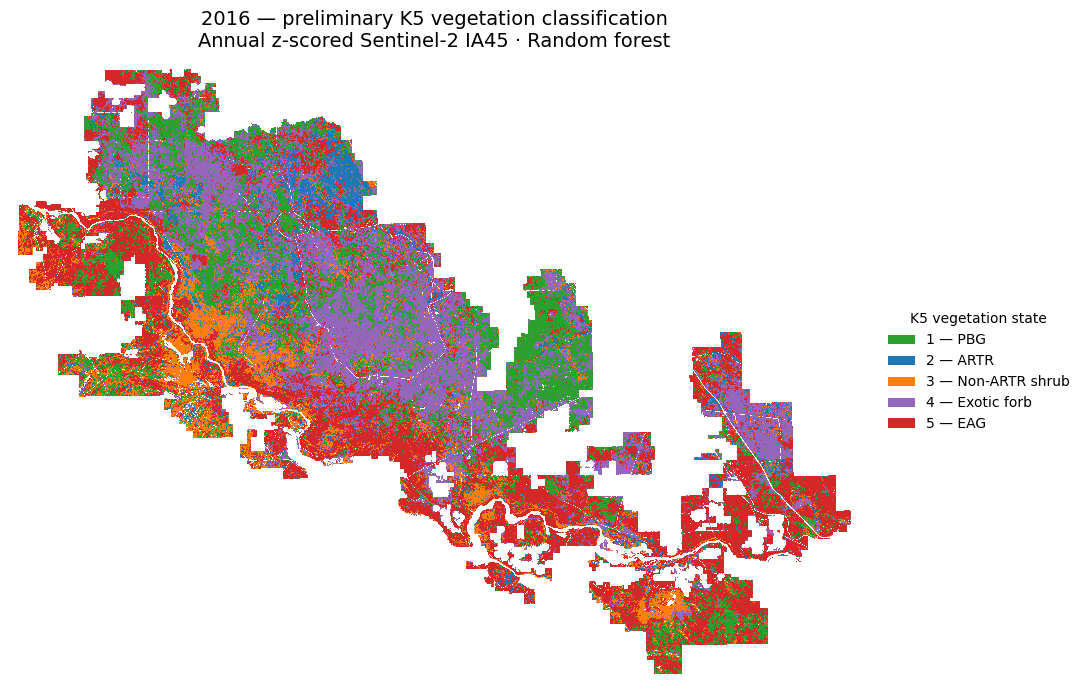

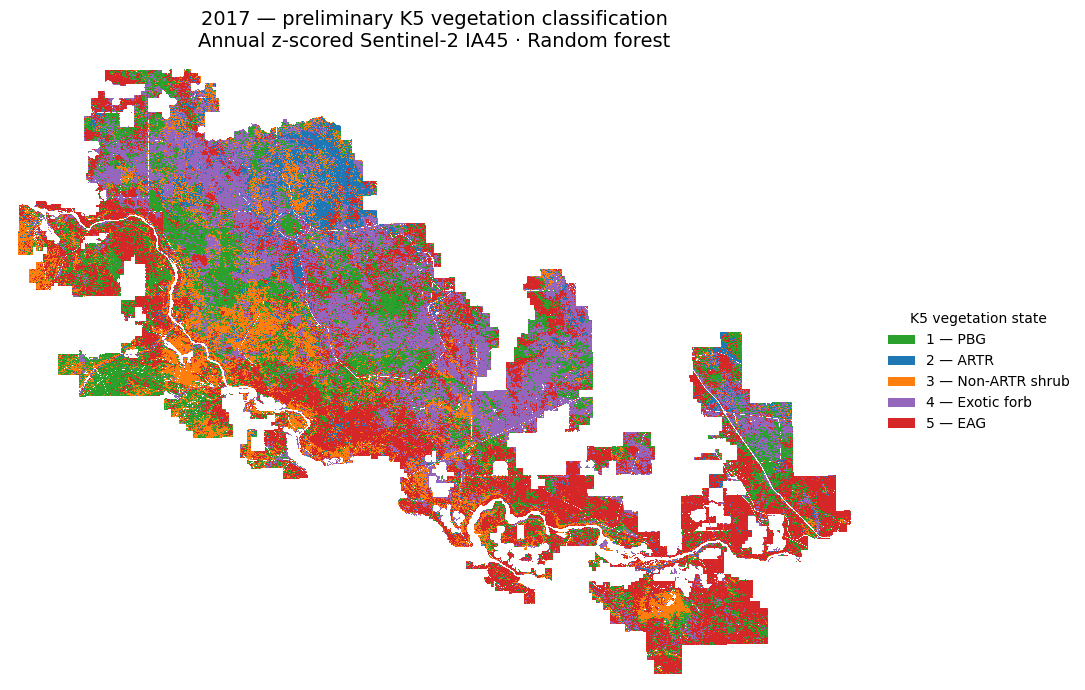

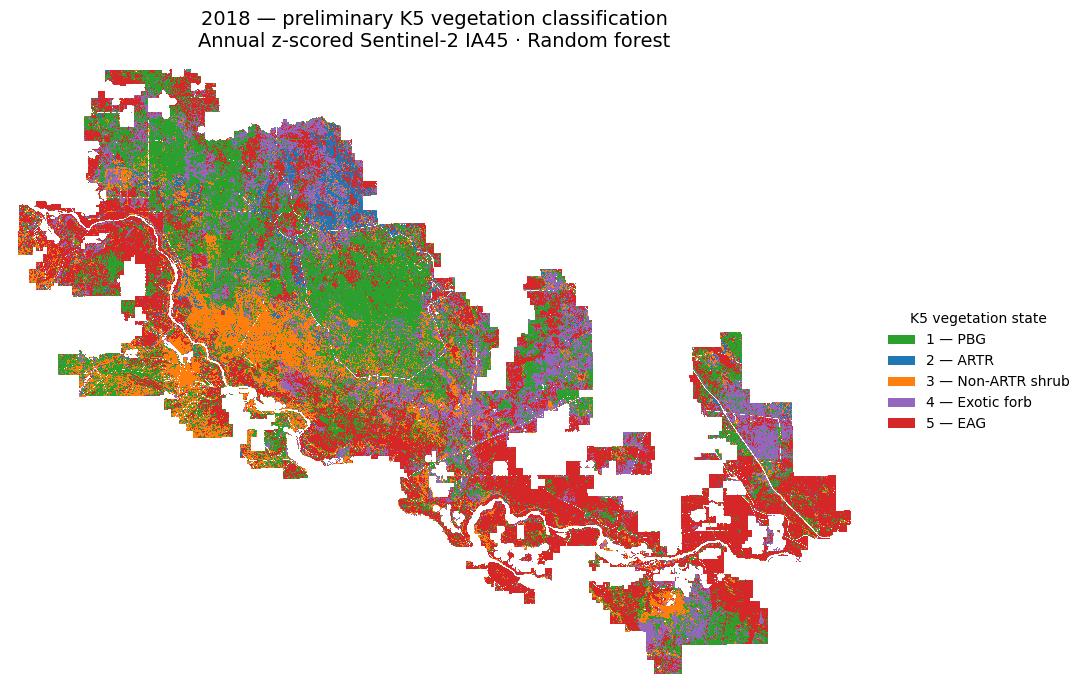

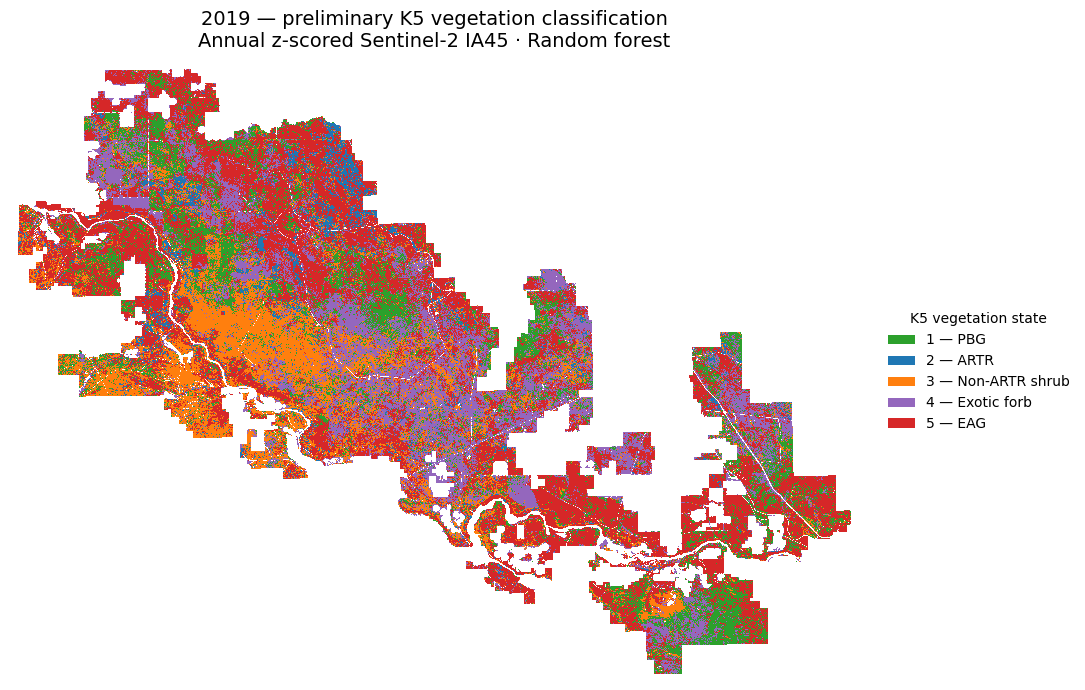

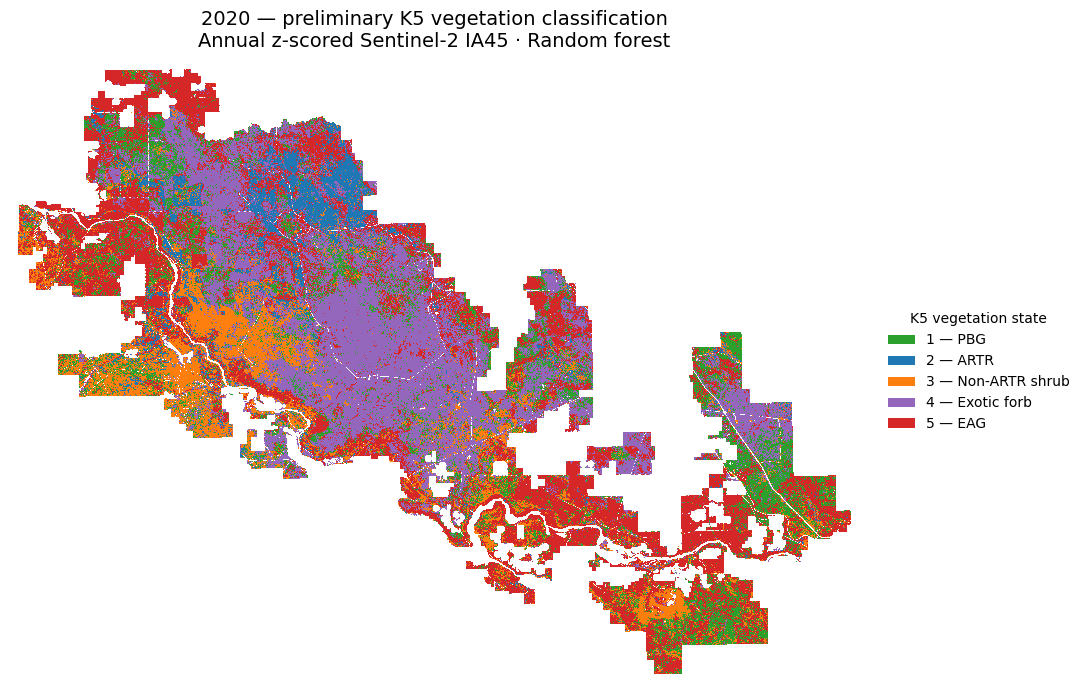

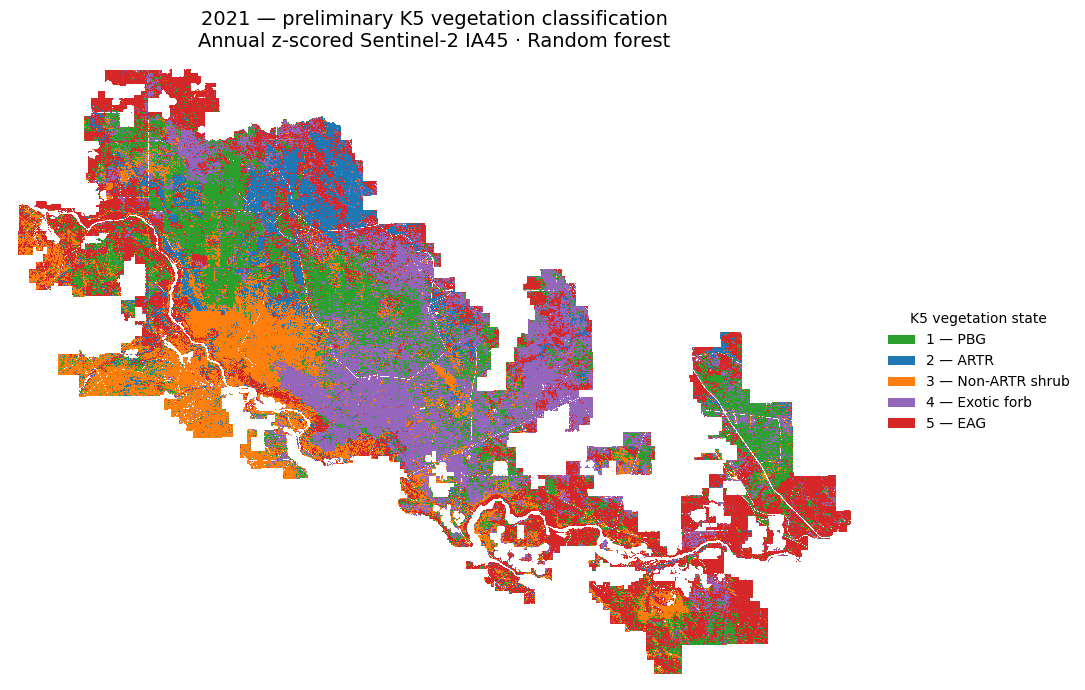

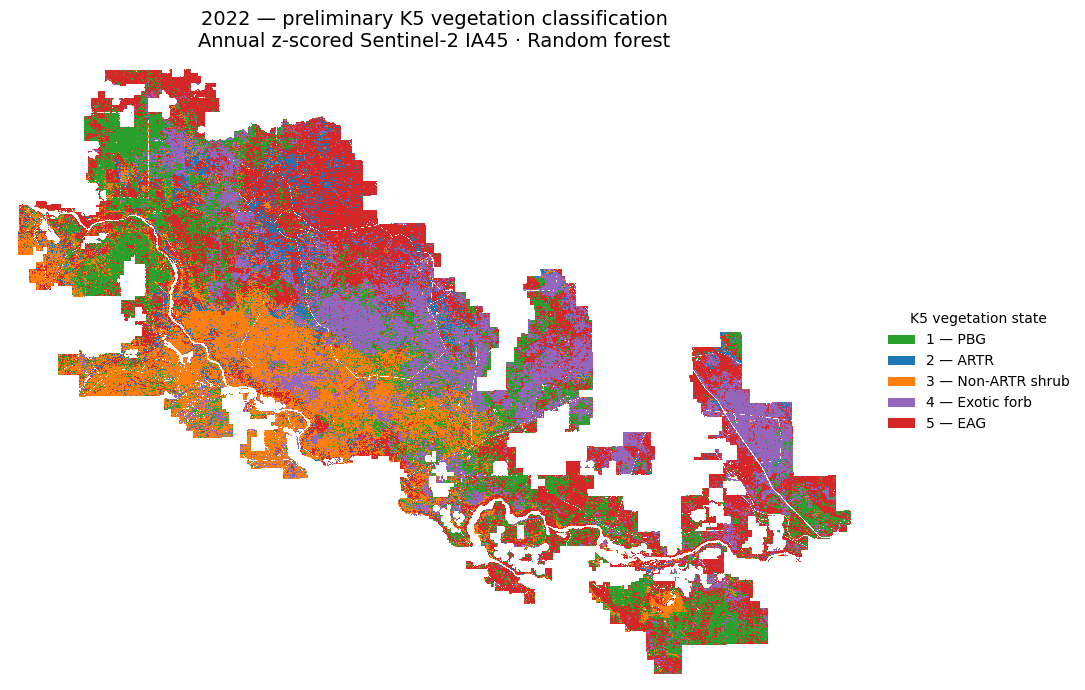

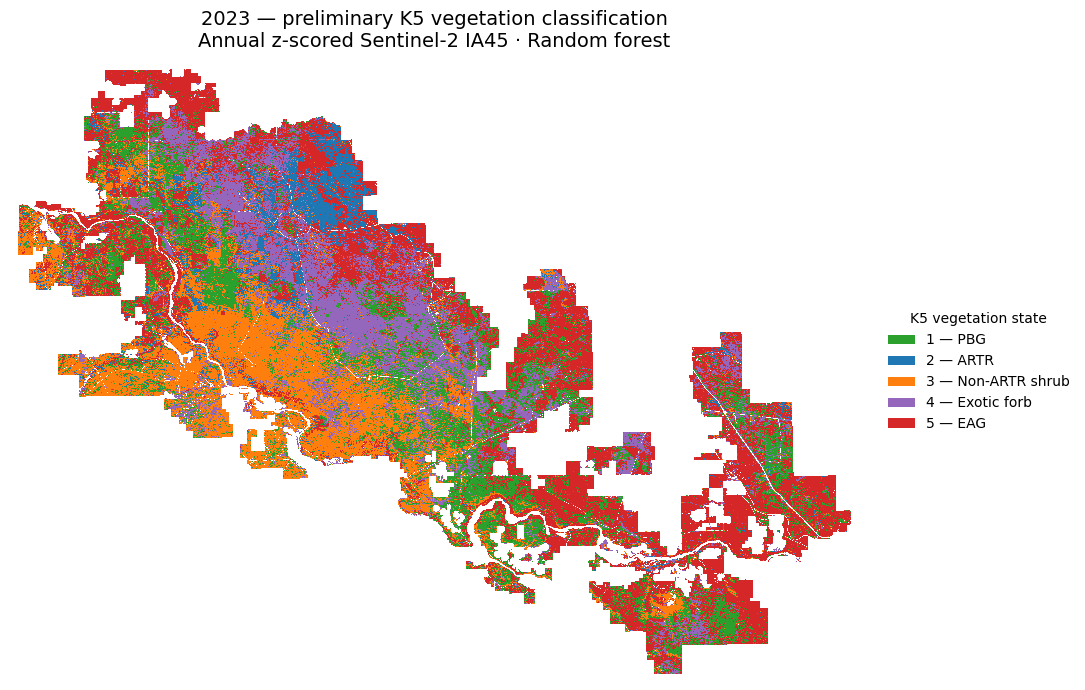

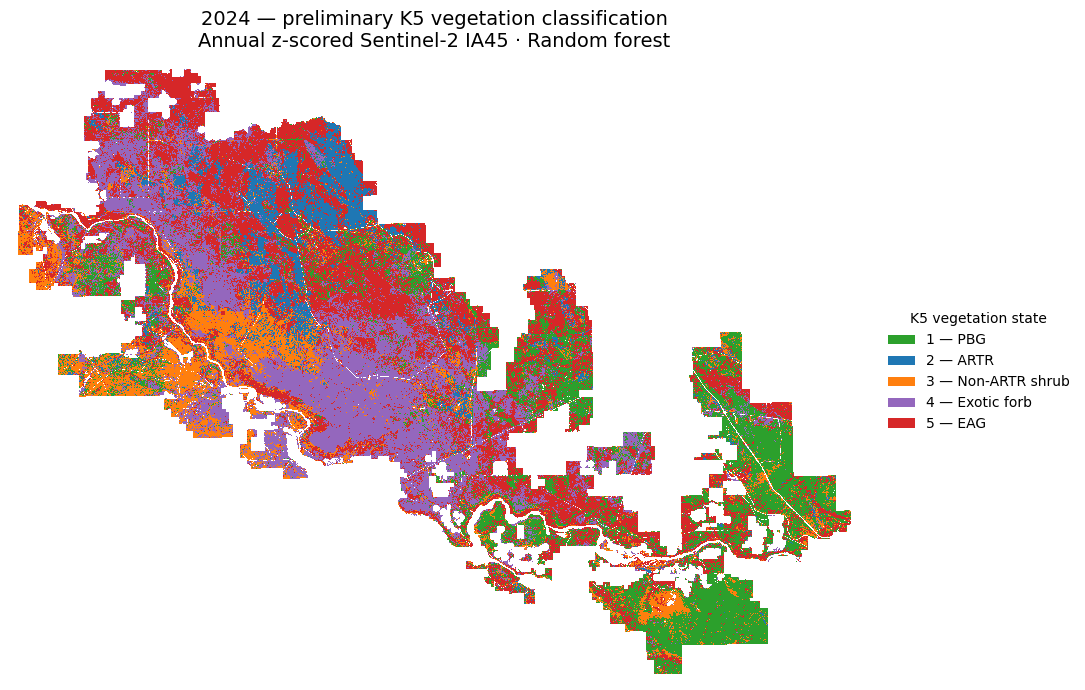

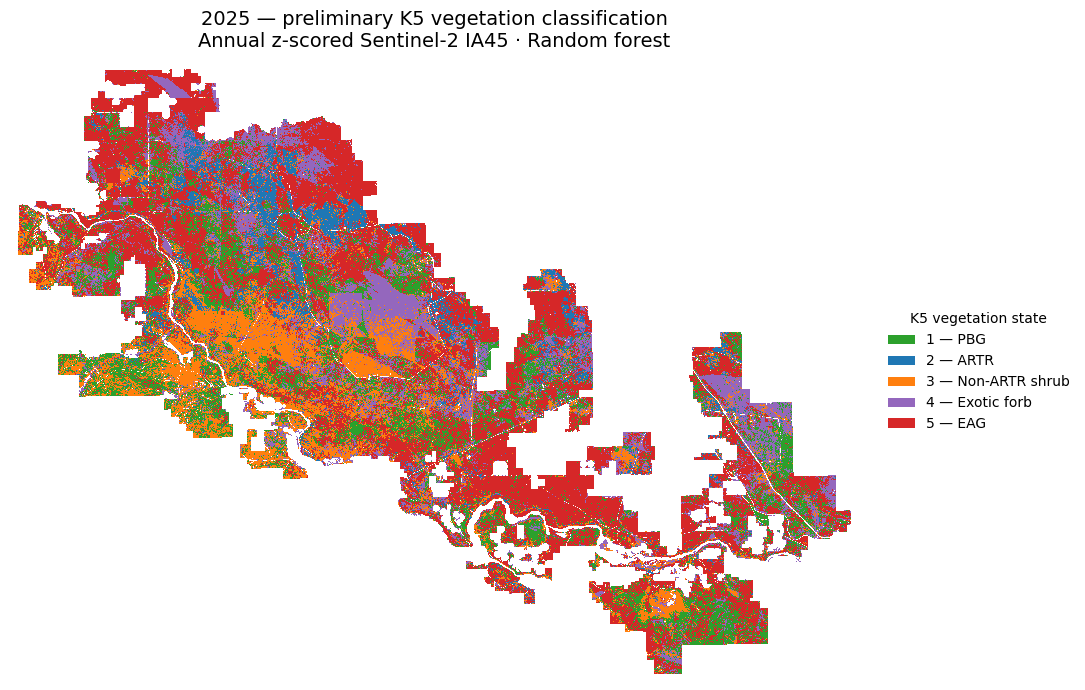

In [18]:
# =============================================================================
# DISPLAY ANNUAL K5 RANDOM-FOREST MAPS — TRUE NCA ONLY
# =============================================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from rasterio.features import geometry_mask


# -----------------------------------------------------------------------------
# PATHS / SETTINGS
# -----------------------------------------------------------------------------

MAP_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5"
)

NCA_BOUNDARY = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)

YEARS = list(
    range(
        2016,
        2026,
    )
)

MODEL_NAME = "random_forest"


# -----------------------------------------------------------------------------
# K5 ECOLOGICAL LABELS
# -----------------------------------------------------------------------------

K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}


# -----------------------------------------------------------------------------
# CATEGORICAL COLORS
#
# Easy to replace later with the final STEP palette.
# -----------------------------------------------------------------------------

tab10 = plt.get_cmap(
    "tab10"
)

K5_COLORS = {
    1: tab10(2),   # PBG
    2: tab10(0),   # ARTR
    3: tab10(1),   # Non-ARTR shrub
    4: tab10(4),   # Exotic forb
    5: tab10(3),   # EAG
}

cmap = ListedColormap(
    [
        K5_COLORS[i]
        for i in range(
            1,
            6,
        )
    ]
)

norm = BoundaryNorm(
    np.arange(
        0.5,
        6.5,
        1.0,
    ),
    cmap.N,
)


legend_handles = [
    Patch(
        facecolor=K5_COLORS[code],
        edgecolor="none",
        label=f"{code} — {K5_LABELS[code]}",
    )
    for code in range(
        1,
        6,
    )
]


# -----------------------------------------------------------------------------
# LOAD TRUE NCA BOUNDARY
# -----------------------------------------------------------------------------

nca = gpd.read_file(
    NCA_BOUNDARY
)


# -----------------------------------------------------------------------------
# DISPLAY EACH YEAR
# -----------------------------------------------------------------------------

for year in YEARS:

    raster_path = (
        MAP_DIR
        / f"K5_AnnualZScore_{MODEL_NAME}_{year}_class.tif"
    )


    if not raster_path.exists():

        print(
            f"{year}: raster not found — skipping"
        )

        continue


    with rasterio.open(
        raster_path
    ) as src:

        arr = src.read(
            1
        )

        transform = src.transform

        bounds = src.bounds

        raster_crs = src.crs


        # -------------------------------------------------------------
        # Reproject NCA boundary to raster CRS if necessary.
        # -------------------------------------------------------------

        nca_raster = nca.to_crs(
            raster_crs
        )


        # -------------------------------------------------------------
        # Exact polygon mask.
        # True inside NCA.
        # -------------------------------------------------------------

        inside_nca = geometry_mask(
            nca_raster.geometry,
            out_shape=arr.shape,
            transform=transform,
            invert=True,
        )


        # Mask nodata / outside true NCA.
        display_arr = np.ma.masked_where(
            (~inside_nca)
            | (arr == 0),
            arr,
        )


        # -------------------------------------------------------------
        # TRUE NCA DISPLAY EXTENT
        # -------------------------------------------------------------

        xmin, ymin, xmax, ymax = (
            nca_raster.total_bounds
        )

        xpad = (
            xmax
            - xmin
        ) * 0.01

        ypad = (
            ymax
            - ymin
        ) * 0.01


        # -------------------------------------------------------------
        # FIGURE
        # -------------------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(
                11,
                7,
            )
        )


        ax.imshow(
            display_arr,
            cmap=cmap,
            norm=norm,
            extent=[
                bounds.left,
                bounds.right,
                bounds.bottom,
                bounds.top,
            ],
            origin="upper",
            interpolation="nearest",
        )


        ax.set_xlim(
            xmin - xpad,
            xmax + xpad,
        )

        ax.set_ylim(
            ymin - ypad,
            ymax + ypad,
        )


        ax.set_title(
            f"{year} — preliminary K5 vegetation classification\n"
            "Annual z-scored Sentinel-2 IA45 · Random forest",
            fontsize=14,
            pad=12,
        )


        # -------------------------------------------------------------
        # CLEAN MAP APPEARANCE
        # -------------------------------------------------------------

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(
                False
            )


        ax.legend(
            handles=legend_handles,
            title="K5 vegetation state",
            loc="center left",
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            frameon=False,
        )


        plt.tight_layout()
        plt.show()
        plt.close(
            fig
        )

In [19]:
# =============================================================================
# K5 MAP STATISTICS — CLASS AREA, TEMPORAL AGREEMENT, UNCERTAINTY, ENDMEMBERS
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from rasterio.features import geometry_mask


# -----------------------------------------------------------------------------
# PATHS
# -----------------------------------------------------------------------------

MAP_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5"
)

NCA_BOUNDARY = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)

MODEL_NAME = "random_forest"

YEARS = list(
    range(
        2016,
        2026,
    )
)


K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}


# -----------------------------------------------------------------------------
# HIGH-CONFIDENCE / "ENDMEMBER" THRESHOLDS
#
# These are diagnostic thresholds, not calibrated probability statements.
# RF predict_proba values are relative classifier confidence.
# -----------------------------------------------------------------------------

PMAX_THRESHOLD = 0.80
MARGIN_THRESHOLD = 0.40

# Entropy normalized to [0,1] relative to five classes.
LOG_K = np.log(
    5.0
)


# -----------------------------------------------------------------------------
# LOAD TRUE NCA
# -----------------------------------------------------------------------------

nca = gpd.read_file(
    NCA_BOUNDARY
)


# -----------------------------------------------------------------------------
# STORAGE
# -----------------------------------------------------------------------------

annual_class_rows = []
annual_uncertainty_rows = []
class_uncertainty_rows = []
endmember_rows = []

class_arrays = {}
valid_masks = {}


# =============================================================================
# 1. ANNUAL MAP STATISTICS
# =============================================================================

for year in YEARS:

    class_path = (
        MAP_DIR
        / f"K5_AnnualZScore_{MODEL_NAME}_{year}_class.tif"
    )

    uncertainty_path = (
        MAP_DIR
        / f"K5_AnnualZScore_{MODEL_NAME}_{year}_uncertainty.tif"
    )


    if not class_path.exists():

        print(
            f"{year}: class raster missing — skipping"
        )

        continue


    with rasterio.open(
        class_path
    ) as src:

        classes = src.read(
            1
        )

        transform = src.transform

        raster_crs = src.crs

        pixel_area_m2 = abs(
            src.transform.a
            * src.transform.e
        )


        nca_raster = nca.to_crs(
            raster_crs
        )


        inside_nca = geometry_mask(
            nca_raster.geometry,
            out_shape=classes.shape,
            transform=transform,
            invert=True,
        )


        valid = (
            inside_nca
            & (
                classes
                > 0
            )
        )


    class_arrays[
        year
    ] = classes

    valid_masks[
        year
    ] = valid


    n_valid = int(
        valid.sum()
    )


    # -------------------------------------------------------------------------
    # CLASS COMPOSITION
    # -------------------------------------------------------------------------

    for code, label in K5_LABELS.items():

        class_mask = (
            valid
            & (
                classes
                == code
            )
        )

        n_pixels = int(
            class_mask.sum()
        )


        annual_class_rows.append(
            {
                "Year": year,
                "class_code": code,
                "class_label": label,
                "n_pixels": n_pixels,
                "fraction": (
                    n_pixels
                    / n_valid
                ),
                "percent": (
                    100.0
                    * n_pixels
                    / n_valid
                ),
                "area_km2": (
                    n_pixels
                    * pixel_area_m2
                    / 1e6
                ),
            }
        )


    # -------------------------------------------------------------------------
    # UNCERTAINTY
    # -------------------------------------------------------------------------

    if uncertainty_path.exists():

        with rasterio.open(
            uncertainty_path
        ) as src:

            pmax = src.read(
                1
            ).astype(
                np.float32
            )

            margin = src.read(
                2
            ).astype(
                np.float32
            )

            entropy = src.read(
                3
            ).astype(
                np.float32
            )


        uncertainty_valid = (
            valid
            & np.isfinite(
                pmax
            )
            & np.isfinite(
                margin
            )
            & np.isfinite(
                entropy
            )
            & (
                pmax
                >= 0
            )
            & (
                margin
                >= 0
            )
            & (
                entropy
                >= 0
            )
        )


        normalized_entropy = (
            entropy
            / LOG_K
        )


        annual_uncertainty_rows.append(
            {
                "Year": year,
                "mean_pmax": np.mean(
                    pmax[
                        uncertainty_valid
                    ]
                ),
                "median_pmax": np.median(
                    pmax[
                        uncertainty_valid
                    ]
                ),
                "mean_margin": np.mean(
                    margin[
                        uncertainty_valid
                    ]
                ),
                "median_margin": np.median(
                    margin[
                        uncertainty_valid
                    ]
                ),
                "mean_normalized_entropy": np.mean(
                    normalized_entropy[
                        uncertainty_valid
                    ]
                ),
                "median_normalized_entropy": np.median(
                    normalized_entropy[
                        uncertainty_valid
                    ]
                ),
            }
        )


        # ---------------------------------------------------------------------
        # CLASS-SPECIFIC CONFIDENCE + ENDMEMBER AREA
        # ---------------------------------------------------------------------

        for code, label in K5_LABELS.items():

            class_mask = (
                uncertainty_valid
                & (
                    classes
                    == code
                )
            )


            n_class = int(
                class_mask.sum()
            )


            if n_class == 0:

                continue


            high_conf = (
                class_mask
                & (
                    pmax
                    >= PMAX_THRESHOLD
                )
                & (
                    margin
                    >= MARGIN_THRESHOLD
                )
            )


            n_high = int(
                high_conf.sum()
            )


            class_uncertainty_rows.append(
                {
                    "Year": year,
                    "class_code": code,
                    "class_label": label,
                    "n_pixels": n_class,
                    "mean_pmax": np.mean(
                        pmax[
                            class_mask
                        ]
                    ),
                    "median_pmax": np.median(
                        pmax[
                            class_mask
                        ]
                    ),
                    "mean_margin": np.mean(
                        margin[
                            class_mask
                        ]
                    ),
                    "median_margin": np.median(
                        margin[
                            class_mask
                        ]
                    ),
                    "mean_normalized_entropy": np.mean(
                        normalized_entropy[
                            class_mask
                        ]
                    ),
                }
            )


            endmember_rows.append(
                {
                    "Year": year,
                    "class_code": code,
                    "class_label": label,
                    "n_class_pixels": n_class,
                    "n_high_confidence": n_high,
                    "fraction_high_confidence": (
                        n_high
                        / n_class
                    ),
                    "percent_high_confidence": (
                        100.0
                        * n_high
                        / n_class
                    ),
                    "high_confidence_area_km2": (
                        n_high
                        * pixel_area_m2
                        / 1e6
                    ),
                }
            )


# =============================================================================
# 2. TEMPORAL AGREEMENT
# =============================================================================

agreement_rows = []
transition_records = []


available_years = sorted(
    class_arrays
)


for year_a, year_b in zip(
    available_years[:-1],
    available_years[1:],
):

    a = class_arrays[
        year_a
    ]

    b = class_arrays[
        year_b
    ]


    valid = (
        valid_masks[
            year_a
        ]
        & valid_masks[
            year_b
        ]
    )


    aa = a[
        valid
    ]

    bb = b[
        valid
    ]


    agreement = np.mean(
        aa
        == bb
    )


    agreement_rows.append(
        {
            "year_from": year_a,
            "year_to": year_b,
            "n_pixels": len(
                aa
            ),
            "agreement": agreement,
            "percent_same": (
                100.0
                * agreement
            ),
            "percent_changed": (
                100.0
                * (
                    1.0
                    - agreement
                )
            ),
        }
    )


    # -------------------------------------------------------------------------
    # FULL TRANSITION MATRIX
    # -------------------------------------------------------------------------

    for from_code, from_label in K5_LABELS.items():

        from_mask = (
            aa
            == from_code
        )

        n_from = int(
            from_mask.sum()
        )


        if n_from == 0:

            continue


        for to_code, to_label in K5_LABELS.items():

            n_transition = int(
                np.sum(
                    from_mask
                    & (
                        bb
                        == to_code
                    )
                )
            )


            transition_records.append(
                {
                    "year_from": year_a,
                    "year_to": year_b,
                    "from_code": from_code,
                    "from_label": from_label,
                    "to_code": to_code,
                    "to_label": to_label,
                    "n_pixels": n_transition,
                    "fraction_of_from_class": (
                        n_transition
                        / n_from
                    ),
                }
            )


# =============================================================================
# 3. PER-PIXEL PERSISTENCE ACROSS ALL AVAILABLE YEARS
# =============================================================================

stack = np.stack(
    [
        class_arrays[
            year
        ]
        for year in available_years
    ],
    axis=0,
)


common_valid = np.logical_and.reduce(
    [
        valid_masks[
            year
        ]
        for year in available_years
    ]
)


stack_valid = stack[
    :,
    common_valid
]


# Number of year-to-year class changes per pixel.
n_changes = np.sum(
    stack_valid[
        1:
    ]
    != stack_valid[
        :-1
    ],
    axis=0,
)


# Number of unique classes occupied through time.
n_unique = np.array(
    [
        len(
            np.unique(
                stack_valid[
                    :,
                    i
                ]
            )
        )
        for i in range(
            stack_valid.shape[
                1
            ]
        )
    ],
    dtype=np.uint8,
)


# Modal class and modal-class fraction.
modal_class = np.zeros(
    stack_valid.shape[
        1
    ],
    dtype=np.uint8,
)

modal_fraction = np.zeros(
    stack_valid.shape[
        1
    ],
    dtype=np.float32,
)


for i in range(
    stack_valid.shape[
        1
    ]
):

    counts = np.bincount(
        stack_valid[
            :,
            i
        ],
        minlength=6,
    )[
        1:
    ]

    modal_class[
        i
    ] = (
        np.argmax(
            counts
        )
        + 1
    )

    modal_fraction[
        i
    ] = (
        counts.max()
        / len(
            available_years
        )
    )


persistence_summary = pd.DataFrame(
    {
        "metric": [
            "n_common_pixels",
            "mean_year_to_year_changes",
            "median_year_to_year_changes",
            "fraction_never_changes",
            "fraction_one_class_only",
            "mean_modal_fraction",
            "fraction_modal_ge_0p80",
        ],
        "value": [
            stack_valid.shape[
                1
            ],
            np.mean(
                n_changes
            ),
            np.median(
                n_changes
            ),
            np.mean(
                n_changes
                == 0
            ),
            np.mean(
                n_unique
                == 1
            ),
            np.mean(
                modal_fraction
            ),
            np.mean(
                modal_fraction
                >= 0.80
            ),
        ],
    }
)


# =============================================================================
# 4. TABLES
# =============================================================================

annual_class_df = pd.DataFrame(
    annual_class_rows
)

annual_uncertainty_df = pd.DataFrame(
    annual_uncertainty_rows
)

class_uncertainty_df = pd.DataFrame(
    class_uncertainty_rows
)

endmember_df = pd.DataFrame(
    endmember_rows
)

agreement_df = pd.DataFrame(
    agreement_rows
)

transition_df = pd.DataFrame(
    transition_records
)


print(
    "\n"
    + "=" * 90
)

print(
    "ANNUAL CLASS COMPOSITION (%)"
)

print(
    "=" * 90
)

display(
    annual_class_df.pivot(
        index="Year",
        columns="class_label",
        values="percent",
    )
    .round(
        1
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "ANNUAL UNCERTAINTY"
)

print(
    "=" * 90
)

display(
    annual_uncertainty_df.round(
        3
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "CLASS-SPECIFIC CONFIDENCE"
)

print(
    "=" * 90
)

display(
    class_uncertainty_df[
        [
            "Year",
            "class_label",
            "mean_pmax",
            "mean_margin",
            "mean_normalized_entropy",
        ]
    ].round(
        3
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    f"HIGH-CONFIDENCE ENDMEMBERS "
    f"(pmax ≥ {PMAX_THRESHOLD:.2f}, margin ≥ {MARGIN_THRESHOLD:.2f})"
)

print(
    "=" * 90
)

display(
    endmember_df.pivot(
        index="Year",
        columns="class_label",
        values="percent_high_confidence",
    )
    .round(
        1
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "CONSECUTIVE-YEAR MAP AGREEMENT"
)

print(
    "=" * 90
)

display(
    agreement_df.round(
        2
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "WHOLE-PERIOD PIXEL PERSISTENCE"
)

print(
    "=" * 90
)

display(
    persistence_summary
)


# =============================================================================
# 5. MEAN CLASS STATISTICS ACROSS YEARS
# =============================================================================

mean_class_stats = (
    annual_class_df
    .groupby(
        [
            "class_code",
            "class_label",
        ],
        as_index=False,
    )
    .agg(
        mean_percent=(
            "percent",
            "mean",
        ),
        sd_percent=(
            "percent",
            "std",
        ),
        min_percent=(
            "percent",
            "min",
        ),
        max_percent=(
            "percent",
            "max",
        ),
    )
)


mean_endmember_stats = (
    endmember_df
    .groupby(
        [
            "class_code",
            "class_label",
        ],
        as_index=False,
    )
    .agg(
        mean_percent_high_confidence=(
            "percent_high_confidence",
            "mean",
        ),
        min_percent_high_confidence=(
            "percent_high_confidence",
            "min",
        ),
        max_percent_high_confidence=(
            "percent_high_confidence",
            "max",
        ),
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "MEAN ANNUAL CLASS COMPOSITION"
)

print(
    "=" * 90
)

display(
    mean_class_stats.round(
        2
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "MEAN HIGH-CONFIDENCE FRACTION WITHIN EACH CLASS"
)

print(
    "=" * 90
)

display(
    mean_endmember_stats.round(
        2
    )
)


ANNUAL CLASS COMPOSITION (%)


class_label,ARTR,EAG,Exotic forb,Non-ARTR shrub,PBG
Year,,,,,
2016,5.6,33.2,27.8,10.9,22.6
2017,5.8,34.1,23.9,13.2,22.9
2018,4.0,36.5,16.4,14.1,29.0
2019,5.0,40.2,20.9,17.2,16.8
2020,7.0,33.2,30.6,13.4,15.8
2021,8.9,29.8,22.9,17.5,20.8
2022,5.2,34.1,20.3,19.4,21.0
2023,6.5,34.8,18.4,20.2,20.1
2024,8.4,34.5,25.2,12.4,19.5



ANNUAL UNCERTAINTY


,Year,mean_pmax,median_pmax,mean_margin,median_margin,mean_normalized_entropy,median_normalized_entropy
0,2016,0.476,0.453,0.231,0.187,0.787,0.803
1,2017,0.451,0.431,0.197,0.156,0.809,0.821
2,2018,0.496,0.469,0.256,0.207,0.767,0.790
3,2019,0.460,0.437,0.217,0.172,0.807,0.831
4,2020,0.472,0.448,0.228,0.182,0.792,0.810
5,2021,0.480,0.456,0.235,0.192,0.783,0.805
6,2022,0.435,0.422,0.179,0.149,0.830,0.841
7,2023,0.472,0.444,0.231,0.184,0.793,0.825
8,2024,0.459,0.447,0.198,0.166,0.799,0.803
9,2025,0.481,0.448,0.237,0.180,0.778,0.816



CLASS-SPECIFIC CONFIDENCE


...

,metric,value
0,n_common_pixels,2.199469e+07
1,mean_year_to_year_changes,4.174328e+00
2,median_year_to_year_changes,4.000000e+00
3,fraction_never_changes,7.837391e-02
4,fraction_one_class_only,7.837391e-02
5,mean_modal_fraction,6.488340e-01
6,fraction_modal_ge_0p80,3.071614e-01



MEAN ANNUAL CLASS COMPOSITION


,class_code,class_label,mean_percent,sd_percent,min_percent,max_percent
0,1,PBG,20.69,3.72,15.76,29.02
1,2,ARTR,6.38,1.56,4.00,8.93
2,3,Non-ARTR shrub,15.44,3.09,10.95,20.18
3,4,Exotic forb,22.28,4.74,16.35,30.61
4,5,EAG,35.21,3.47,29.80,41.68



MEAN HIGH-CONFIDENCE FRACTION WITHIN EACH CLASS


,class_code,class_label,mean_percent_high_confidence,min_percent_high_confidence,max_percent_high_confidence
0,1,PBG,0.03,0.00,0.11
1,2,ARTR,0.03,0.00,0.19
2,3,Non-ARTR shrub,0.09,0.00,0.47
3,4,Exotic forb,0.00,0.00,0.00
4,5,EAG,5.42,0.49,10.49


## Interpretation boundary

This is a **five-class classification experiment**, not evidence that K=5 is intrinsically superior to K=8 simply because its predictive metrics may be higher. The response task is coarser and therefore easier.

The relevant questions are:

1. How much does grouped OOF accuracy / balanced accuracy / macro F1 improve when predicting the independently supported K5 vegetation partition?
2. Does LOYO temporal transfer improve consistently across 2016, 2018, and 2025?
3. Which of the five coarse vegetation modes remain difficult to distinguish optically?
4. Does the coarse K5 result support the hypothesis that Sentinel-2 harmonics observe major vegetation modes more reliably than the finer K8 intermediate/codominant structure?

The strongest comparison to the retained K8 classifier is therefore not raw accuracy alone, but the full confusion structure and transfer behavior at each ecological resolution.